In [18]:
%load_ext autoreload
%autoreload 2

import util as yu
from util import *
import util_moments as yum

enss=['b','c','d','e']

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
ens2Njk={'b':725,'c':400,'d':493,'e':516}
path='data_aux/RCs_np.pkl'
with open(path,'rb') as f:
    ens2RCs_np_me=pickle.load(f)
ens2RCs_np={ens:{} for ens in enss}
for ens in enss:
    for key in ens2RCs_np_me[ens]:
        if key.endswith('err'):
            continue
        ens2RCs_np[ens][key]=yu.jackknife_pseudo(ens2RCs_np_me[ens][key],ens2RCs_np_me[ens][f'{key}_err']+1e-10,ens2Njk[ens])[:,0]

In [20]:
supjackQ=True
ej_key2bare_A20at0=yu.load_pkl_reg('ej_key2bare_A20at0', pathlabel="analysis_xJ")
stout=10
key2bare_A20=ej_key2bare_A20at0.copy()
yum.extendBare_avgx(key2bare_A20)
key2phy_A20=yum.convert_key2phy_stout(yum.bareRC2phy_avgx_np(key2bare_A20,ens2RCs_np,supjackQ=supjackQ),stout)

key2phy_A20_AICc=yum.convert_key2phy_stout(yum.bareRC2phy_avgx_np(key2bare_A20,ens2RCs_np,supjackQ=supjackQ,AICcQ=True),stout)

In [21]:
def plot_A20_B20_J(which,key2phy):
    sty = {"jtot": ("gray", "o"), "jq": ("purple", "d"), "jg": ("cyan", "s"),
           "ju": ("red", "^"), "jd": ("green", "v"), "js": ("blue", "<"), "jc": ("orange", ">")}

    if which == "A20":
        rows = [(["jtot", "jq", "jg"], r"$\langle x\rangle_{q,g}$", (0.20, 1.40), [0.5, 1.0], 1.0),
                (["ju", "jd", "js", "jc"], r"$\langle x\rangle_q$", (-0.10, 0.58), [0.0, 0.2, 0.4], 0.0)]
        ratios, figsize = [1.15, 1.0], (5.6, 7.4)
        lab = dict(jtot=r"$\langle x\rangle_N$", jq=r"$\langle x\rangle_q$", jg=r"$\langle x\rangle_g$",
                   ju=r"$\langle x\rangle_u$", jd=r"$\langle x\rangle_d$",
                   js=r"$\langle x\rangle_s$", jc=r"$\langle x\rangle_c$")
    elif which == "B20":
        rows = [(["jtot"], r"$B_{20}^N$", (-0.30, 0.29), [-0.2, 0.0, 0.2], 0.0),
                (["jq", "jg"], r"$B_{20}^{q,g}$", (-0.30, 0.29), [-0.2, 0.0, 0.2], 0.0),
                (["ju", "jd", "js", "jc"], r"$B_{20}^q$", (-0.18, 0.18), [-0.1, 0.0, 0.1], 0.0)]
        ratios, figsize = [1.0, 1.0, 2.0], (5.6, 7.4)
        lab = {j: rf"$B_{{20}}^{{{s}}}$" for j, s in
               zip(["jtot", "jq", "jg", "ju", "jd", "js", "jc"], ["N", "q", "g", "u", "d", "s", "c"])}
    else:
        rows = [(["jtot", "jq", "jg"], r"$J_{q,g}$", (0.08, 0.70), [0.2, 0.5], 0.5),
                (["ju", "jd", "js", "jc"], r"$J_q$", (-0.03, 0.28), [0.0, 0.1, 0.2], 0.0)]
        ratios, figsize = [1.15, 1.0], (5.6, 7.4)
        lab = {j: rf"$J_{{{s}}}$" for j, s in
               zip(["jtot", "jq", "jg", "ju", "jd", "js", "jc"], ["N", "q", "g", "u", "d", "s", "c"])}

    fig, axs = plt.subplots(len(rows), 1, figsize=figsize, sharex=True,
                            gridspec_kw={"height_ratios": ratios, "hspace": 0})
    axs = np.atleast_1d(axs)

    for ax, (js, ylabel, ylim, yticks, ref) in zip(axs, rows):
        for j in js:
            c, m = sty[j]
            x = np.asarray(yum.lat_a2s_plt)
            y, e = map(np.asarray, yu.jackme(key2phy[("a=#_MA", j)]))

            ax.plot(x, y, "--", color=c, lw=2)
            ax.fill_between(x, y - e, y + e, color=c, alpha=0.12)

            xs, ys, es = zip(*[(yu.ens2a[ens]**2, *yu.jackme(key2phy[(ens, j)])) for ens in enss])
            ax.errorbar(xs, ys, yerr=es, fmt=m, color=c, label=lab[j], capsize=6, lw=2, ms=6)

        ax.axhline(ref, color="black", ls=":", lw=2, marker="")
        ax.set(ylabel=ylabel, ylim=ylim, yticks=yticks)
        ax.tick_params(direction="in", top=True, right=True)

        if which=='B20' and j=='jtot':
            pass
        else:
            ax.legend(loc="upper right", frameon=True, ncol=len(js),
                  fontsize=15, handlelength=0.9, columnspacing=0.45,
                  handletextpad=0.25, borderpad=0.25)

    axs[-1].set(xlabel=r"$a^2\ [\mathrm{fm}^2]$", xlim=(0, 0.008),
                xticks=[0.000, 0.003, 0.006])

    t={'A20':'avgx'}[which] if which in ['A20'] else which
    return fig, axs


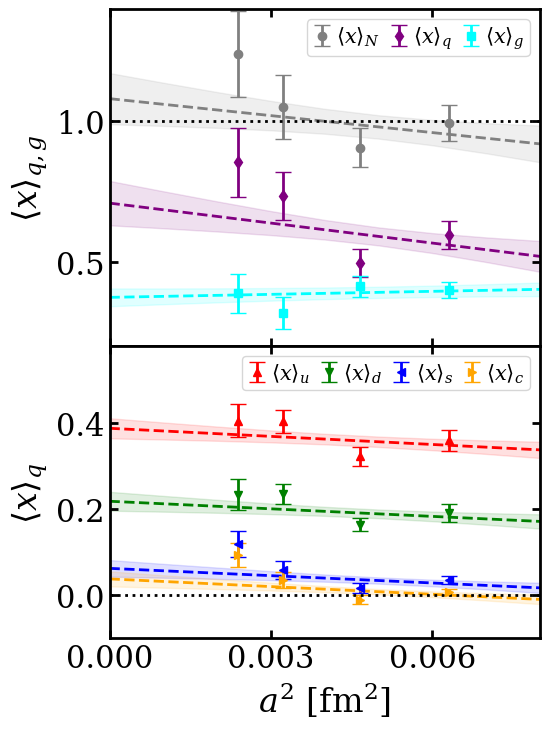
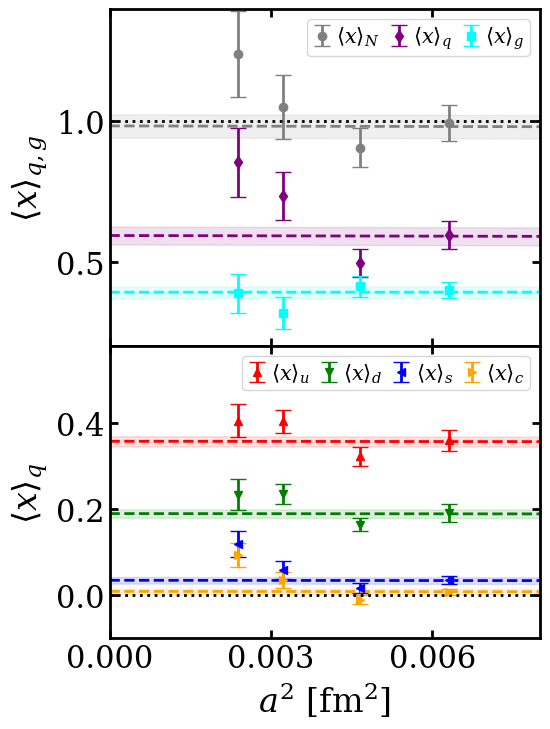

In [32]:
fig1,axs=plot_A20_B20_J('A20',key2phy_A20)
yu.finalizePlot()

fig2,axs=plot_A20_B20_J('A20',key2phy_A20_AICc)
yu.finalizePlot()

yu.display_figs([fig1,fig2],width=500)